<a href="https://colab.research.google.com/github/kamat-v/qc-course-materials/blob/main/notebooks/week05_the_chsh_game.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install qiskit qiskit_aer qiskit-ibm-runtime pylatexenc

In [43]:
import numpy as np
import random
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
import matplotlib.pyplot as plt

$R_y(\theta)=\begin{bmatrix}
\cos(\theta/2) &  -\sin (\theta/2)\\
\sin(\theta/2) & \cos (\theta/2)
\end{bmatrix}$, on the Bloch sphere.

In [44]:
q=QuantumCircuit(2)
#Qubit 0 is |0> by default
#Qubit 1 flipped to |1>
q.x(1)
#Apply a rotation gate to |0>
q.ry(np.pi/4,0)
#Apply a rotation gate to |1>
q.ry(np.pi/2,1)
s=Statevector(q)
s.draw('latex')

<IPython.core.display.Latex object>

The $R_y(\theta)$ gate has the effect of rotating a qubit $|\psi\rangle$ around the $y$-axis by $\theta$ radians. The visualization below demonstrates the action of $R_y(\pi/4)$ and $R_y(\pi/2)$ on $|0\rangle$ and $|1\rangle$ respectively.

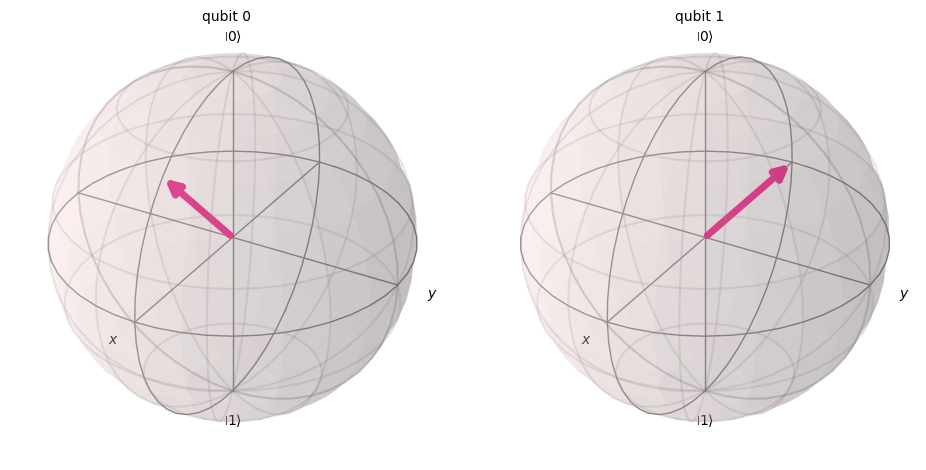

In [45]:
plot_bloch_multivector(s)

Applying $R_y(\theta_1) \otimes R_y(\theta_2)$ to the Bell state $\dfrac{1}{\sqrt{2}} \left( |00\rangle + |11\rangle \right)$

In general, the resulting state has this form:
$$\dfrac{\cos\left(\frac{\theta_1-\theta_2}{2}\right)\left(|00\rangle +|11\rangle \right) + \sin\left(\frac{\theta_1-\theta_2}{2}\right) \left( |10\rangle - |01\rangle \right)}{\sqrt{2}}$$

In [46]:
qc=QuantumCircuit(2)
# Step 1: Apply Hadamard to first qubit
qc.h(0)
# Step 2: Apply CNOT with qubit 0 as control, qubit 1 as target
qc.cx(0, 1)
qc.ry(np.pi/4,0)
qc.ry(np.pi/2,1)
sv=Statevector(qc)
sv.draw('latex')


<IPython.core.display.Latex object>

**The CHSH Game**: Two people, Alice and Bob, are each given a bit, $x$ and $y$ respectively, generated uniformly at random. They have to respond with a bit $a$ and $b$ respectively. They win the game if and only if
$$a\oplus b= x\land y.$$

While Alice and Bob can plan a strategy **before** the game begins, they are not allowed to communicate after it begins, and must respond instantaneously.

What is an optimal (classical) strategy?

In [33]:
def chsh_game(strategy):
    # This function runs the CHSH game, using an input strategy, returning 1 for a win and 0 for a loss.

    # Choose x and y randomly
    x, y = random.randint(0, 1), random.randint(0, 1)

    # Use the strategy to determine a and b
    a, b = strategy(x, y)

    # Decide if the strategy wins or loses
    if (a != b) == (x & y):
        return 1  # Win
    else:
        return 0  # Lose

In [34]:
def sample_classical_strategy (x,y):

  #Alice and Bob choose the same bit

  a=random.randint(0,1)
  b=a
  return a,b

In [40]:
NUM_GAMES = 10000
TOTAL_SCORE = 0

for _ in range(NUM_GAMES):
    TOTAL_SCORE += chsh_game(sample_classical_strategy)

print("Fraction of games won:", TOTAL_SCORE / NUM_GAMES)

Fraction of games won: 0.742


**Quantum Strategy**: It turns out that if Alice and Bob shared an entangled Bell's state (Alice controlling the first qubit, and Bob the second), then a strategy involving $R_y$ gate with suitably chosen rotation angles can help them win with a higher probability.

In [47]:
def create_bell_state():
    qc = QuantumCircuit(2,2)
    # Step 1: Apply Hadamard to first qubit
    qc.h(0)
    # Step 2: Apply CNOT with qubit 0 as control, qubit 1 as target
    qc.cx(0, 1)
    return qc

def create_chsh_circuit(x,y):
    qc = create_bell_state()
    qc.barrier()

    # Alice's strategy -- apply Ry(0) if x is 0, else apply Ry(pi/2)
    if x == 0:
        qc.ry(0, 0)
    else:
        qc.ry(np.pi / 2, 0)


    # Bob's strategy -- apply Ry(pi/4) if y is 0, else apply Ry(-pi/4)
    if y == 0:
        qc.ry(np.pi / 4, 1)
    else:
        qc.ry(-np.pi / 4, 1)
    qc.barrier()
    # Measure the qubits
    qc.measure(0, 0)
    qc.measure(1, 1)
    return qc

**Visualizing the circuits for each of the four $(x,y)$ instances**

(x,y) = (0,0)


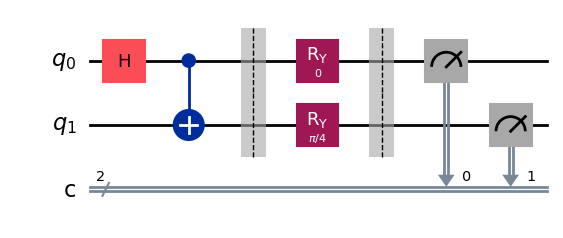

(x,y) = (0,1)


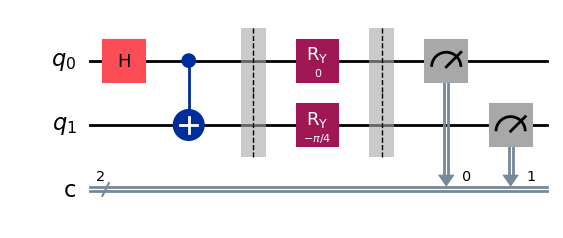

(x,y) = (1,0)


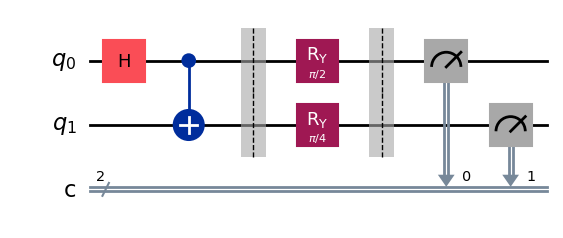

(x,y) = (1,1)


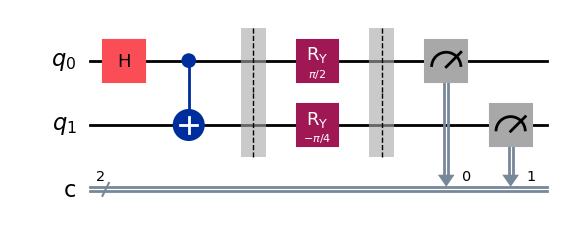

In [37]:
# Draw the four possible circuits
print("(x,y) = (0,0)")
display(create_chsh_circuit(0, 0).draw(output="mpl"))

print("(x,y) = (0,1)")
display(create_chsh_circuit(0, 1).draw(output="mpl"))

print("(x,y) = (1,0)")
display(create_chsh_circuit(1, 0).draw(output="mpl"))

print("(x,y) = (1,1)")
display(create_chsh_circuit(1, 1).draw(output="mpl"))

In [48]:
def quantum_strategy(x, y):
    # This function runs the appropriate quantum circuit defined above
    # one time and returns the measurement results

    # Setting `shots=1` to run the circuit once
    result = AerSimulator().run(create_chsh_circuit(x, y), shots=1).result()
    statistics = result.get_counts()

    # Determine the output bits and return them
    bits = list(statistics.keys())[0]
    a, b = bits[0], bits[1]
    return a, b

In [49]:
NUM_GAMES = 10000
TOTAL_SCORE = 0

for _ in range(NUM_GAMES):
    TOTAL_SCORE += chsh_game(quantum_strategy)

print("Fraction of games won:", TOTAL_SCORE / NUM_GAMES)

Fraction of games won: 0.8515
